<a href="https://colab.research.google.com/github/hdsfdhllh/Capstone-Project_C22-PS142/blob/main/ML_Model_Capstone_Project_Product_Based_Bangkit_2022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! chmod 600 /content/kaggle.json
! KAGGLE_CONFIG_DIR=/content/ kaggle datasets download -d moltean/fruits

100% 1.28G/1.28G [00:11<00:00, 168MB/s]
100% 1.28G/1.28G [00:11<00:00, 124MB/s]


In [ ]:
import zipfile
zip_file = zipfile.ZipFile('/content/fruits.zip')
zip_file.extractall('/tmp/')

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [ ]:
train_generator = ImageDataGenerator(rescale=1/255,
                                     horizontal_flip=True,
                                     vertical_flip=True,
                                     rotation_range=60,
                                     zoom_range=0.3,
                                     fill_mode='nearest')

validation_generator = ImageDataGenerator(rescale=1/255,
                                     horizontal_flip=True,
                                     vertical_flip=True,
                                     rotation_range=60,
                                     zoom_range=0.3,
                                     fill_mode='nearest')

In [ ]:
train_data = train_generator.flow_from_directory('/tmp/fruits-360_dataset/fruits-360/Training',
                                                 batch_size=100,
                                                 class_mode='categorical',
                                                 target_size=(100, 100))

val_data = validation_generator.flow_from_directory('/tmp/fruits-360_dataset/fruits-360/Test',
                                                 batch_size=100,
                                                 class_mode='categorical',
                                                 target_size=(100, 100))

Found 67692 images belonging to 131 classes.
Found 22688 images belonging to 131 classes.


In [ ]:
def create_model():
  
  model = Sequential([   
      Conv2D(16, (3, 3), activation='relu', input_shape=(100, 100, 3)),
      MaxPooling2D(2, 2),
      Conv2D(32, (3, 3), activation='relu'),
      MaxPooling2D(3, 3),
      Flatten(), 
      Dense(128, activation='relu'), 
      Dense(131, activation='softmax')  
  ])
  
  model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy']) 
  
  return model

In [ ]:
model = create_model()

history = model.fit(train_data,
          epochs=25,
          verbose=1,
          validation_data=val_data)

Epoch 1/25
677/677 [==============================] - 246s 344ms/step - loss: 1.4141 - accuracy: 0.6079 - val_loss: 0.7511 - val_accuracy: 0.7617
Epoch 2/25
677/677 [==============================] - 228s 337ms/step - loss: 0.3586 - accuracy: 0.8843 - val_loss: 0.4599 - val_accuracy: 0.8620
Epoch 3/25
677/677 [==============================] - 227s 336ms/step - loss: 0.2161 - accuracy: 0.9278 - val_loss: 0.3664 - val_accuracy: 0.8976
Epoch 4/25
677/677 [==============================] - 226s 334ms/step - loss: 0.1662 - accuracy: 0.9440 - val_loss: 0.3579 - val_accuracy: 0.8986
Epoch 5/25
677/677 [==============================] - 226s 334ms/step - loss: 0.1280 - accuracy: 0.9561 - val_loss: 0.3260 - val_accuracy: 0.9090
Epoch 6/25
677/677 [==============================] - 224s 331ms/step - loss: 0.1160 - accuracy: 0.9608 - val_loss: 0.2539 - val_accuracy: 0.9243
Epoch 7/25
677/677 [==============================] - 225s 333ms/step - loss: 0.0965 - accuracy: 0.9676 - val_loss: 0.2424 -

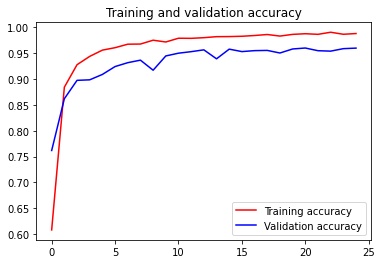

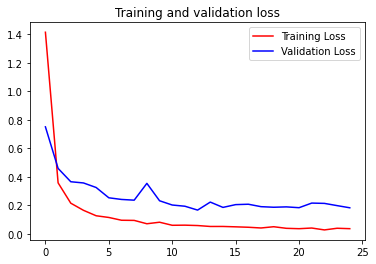

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.savefig("/content/drive/MyDrive/Saved_Model/plot_accuracy.jpg")
plt.show()

print("")

plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()
plt.savefig("/content/drive/MyDrive/Saved_Model/plot_loss.jpg")
plt.show()

In [ ]:
import pickle
from google.colab import files

with open('/content/drive/MyDrive/Saved_Model/history.pkl', 'wb') as f:
  pickle.dump(history.history, f)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p saved_model
model.save('/content/drive/MyDrive/Saved_Model/My_Model')
model.save('/content/drive/MyDrive/Saved_Model/My_Model.h5')

INFO:tensorflow:Assets written to: /content/drive/MyDrive/Saved_Model/My_Model/assets


INFO:tensorflow:Assets written to: /content/drive/MyDrive/Saved_Model/My_Model/assets


In [ ]:
converter = tf.lite.TFLiteConverter.from_saved_model('/content/drive/MyDrive/Saved_Model/My_Model') 
tflite_model = converter.convert()

with open('/content/drive/MyDrive/Saved_Model/My_Model.tflite', 'wb') as f:
  f.write(tflite_model)

In [ ]:
check_model = tf.keras.models.load_model('/content/drive/MyDrive/Saved_Model/My_Model')
check_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 98, 98, 16)        448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 49, 49, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 47, 47, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 15, 15, 32)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 7200)              0         
                                                                 
 dense (Dense)               (None, 128)               9

In [ ]:
check_model = tf.keras.models.load_model('/content/drive/MyDrive/Saved_Model/My_Model.h5')
check_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 98, 98, 16)        448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 49, 49, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 47, 47, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 15, 15, 32)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 7200)              0         
                                                                 
 dense (Dense)               (None, 128)               9